<a href="https://colab.research.google.com/github/arkadjie795/2025-pengolahan-citra-TI-2C/blob/main/jb3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

tugas 1

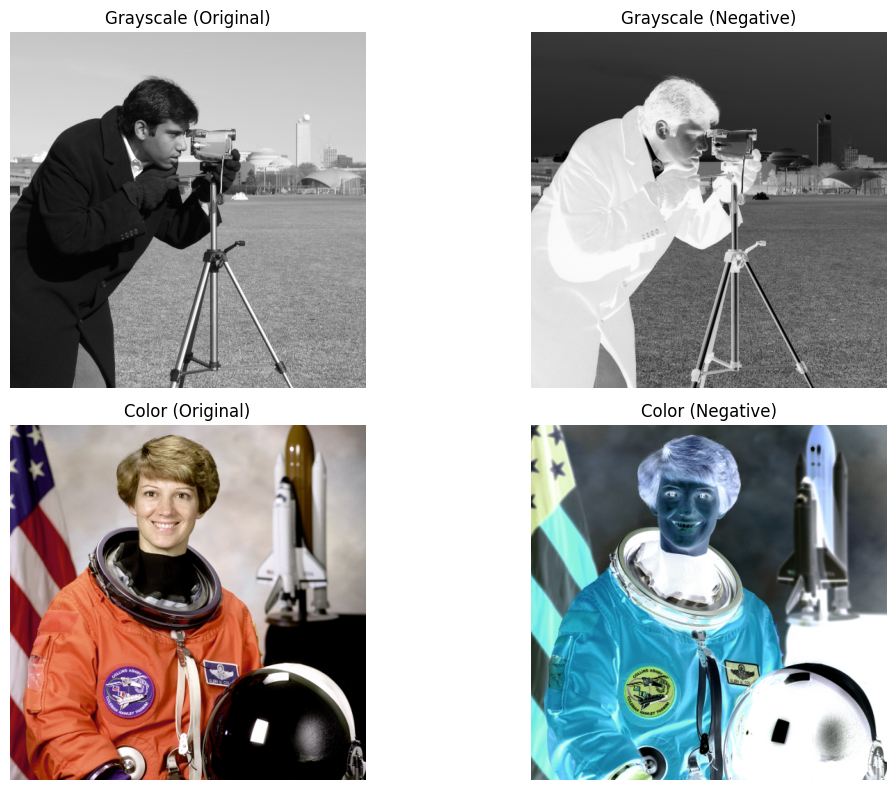

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# Grayscale
image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)
negative_gray = 1.0 - image_gray_float

# Color
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)
negative_color = 1.0 - image_color_float

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')
axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')
axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()


tugas 2

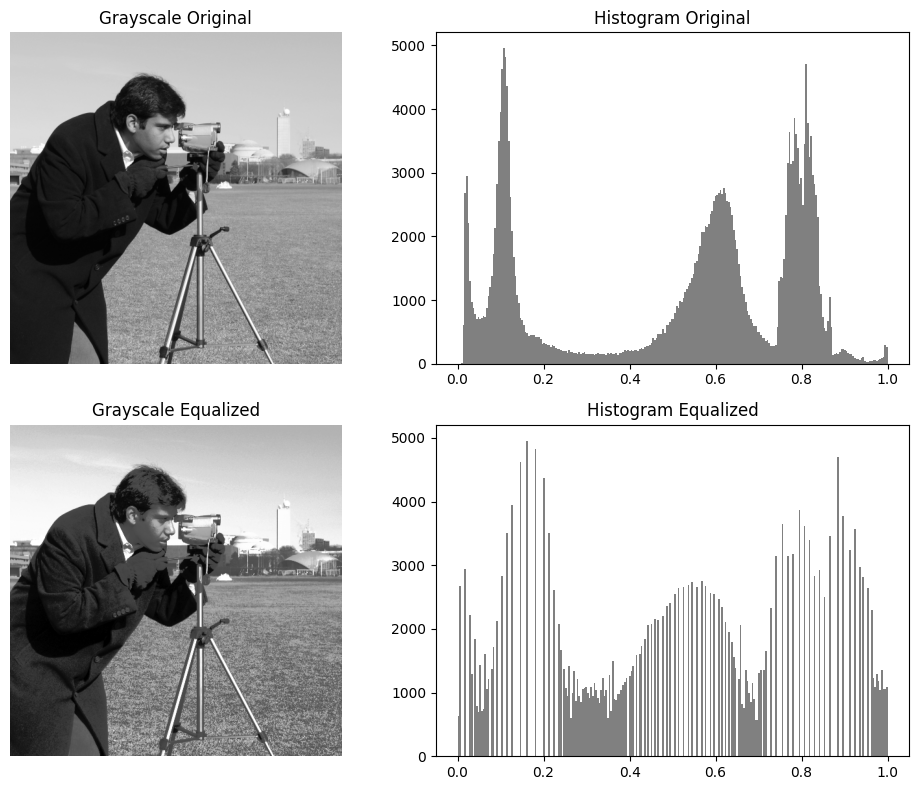

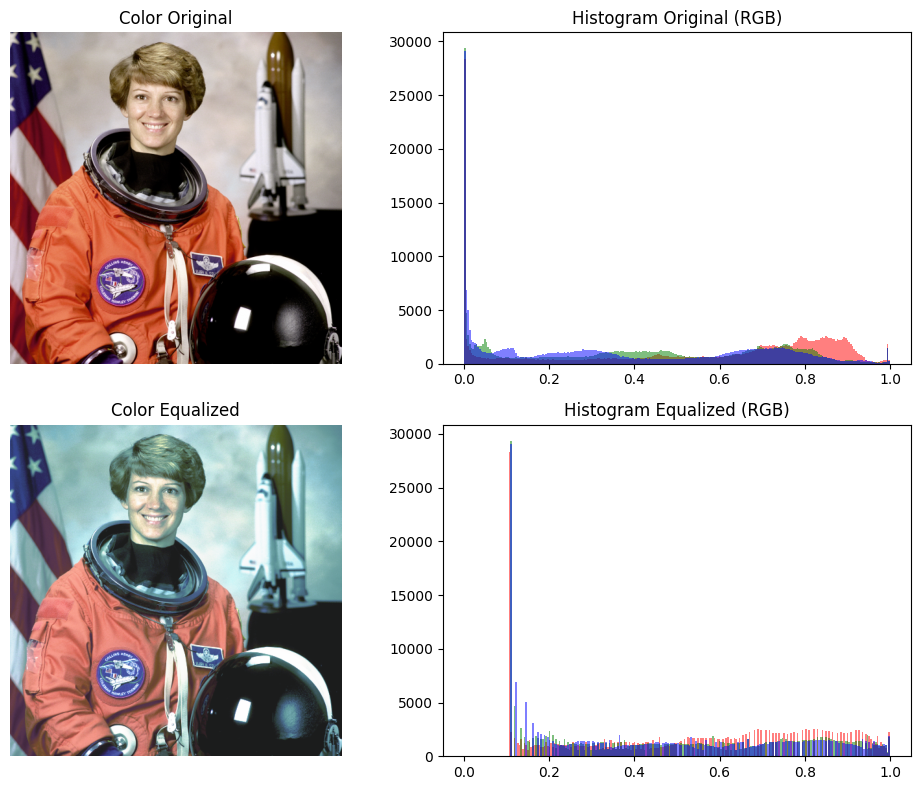

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# Grayscale
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)
hist_gray, _ = np.histogram(image_gray.ravel(), bins=256, range=(0,1))
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, _ = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

# Plot grayscale
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
plt.tight_layout()
plt.show()

# Color
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)
r_eq = exposure.equalize_hist(image_color[:,:,0])
g_eq = exposure.equalize_hist(image_color[:,:,1])
b_eq = exposure.equalize_hist(image_color[:,:,2])
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Plot color
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')
axes2[0, 1].hist(image_color[:,:,0].ravel(), bins=256, range=(0,1), color='red', alpha=0.5)
axes2[0, 1].hist(image_color[:,:,1].ravel(), bins=256, range=(0,1), color='green', alpha=0.5)
axes2[0, 1].hist(image_color[:,:,2].ravel(), bins=256, range=(0,1), color='blue', alpha=0.5)
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized")
axes2[1, 0].axis('off')
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5)
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5)
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5)
axes2[1, 1].set_title("Histogram Equalized (RGB)")
plt.tight_layout()
plt.show()


tugas 3


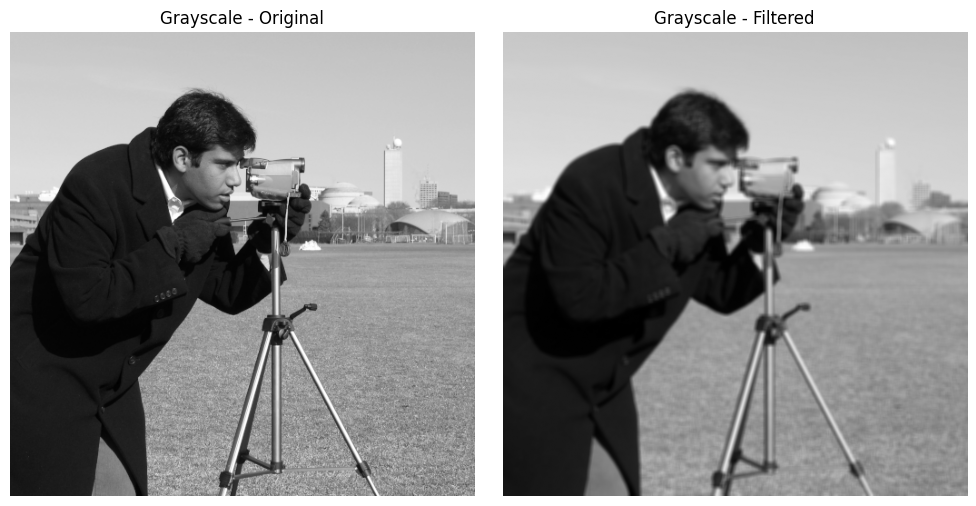

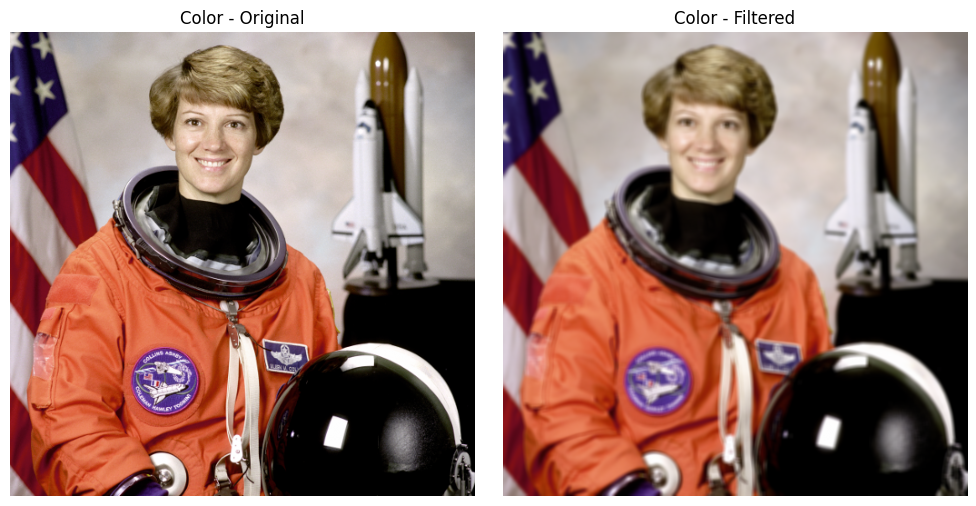

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# Grayscale
gray_img = img_as_float(data.camera())
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size)) / (kernel_size**2)
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# Plot grayscale
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')
axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title("Grayscale - Filtered")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Color
color_img = img_as_float(data.astronaut())
color_filtered = np.zeros_like(color_img)
for c in range(3):
    color_filtered[:,:,c] = ndi.convolve(color_img[:,:,c], kernel, mode='reflect')

# Plot color
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')
axes2[1].imshow(color_filtered)
axes2[1].set_title("Color - Filtered")
axes2[1].axis('off')
plt.tight_layout()
plt.show()


tugas 4

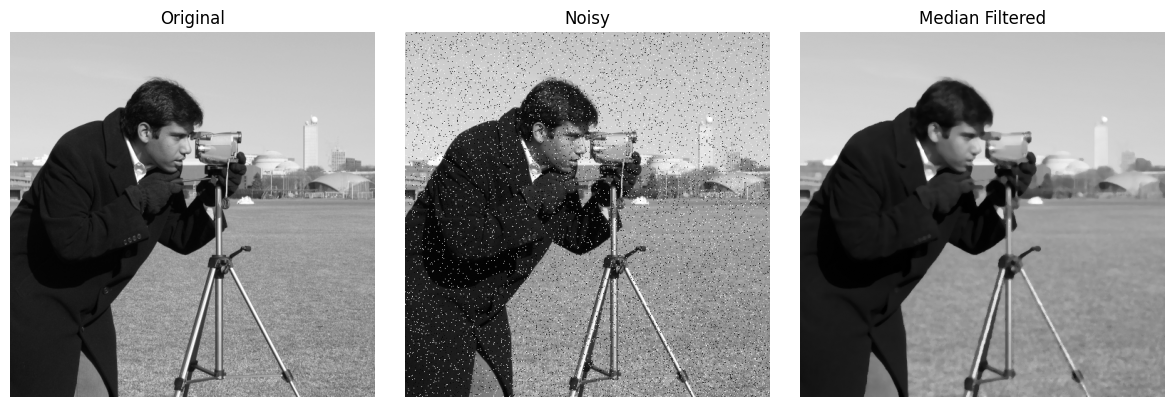

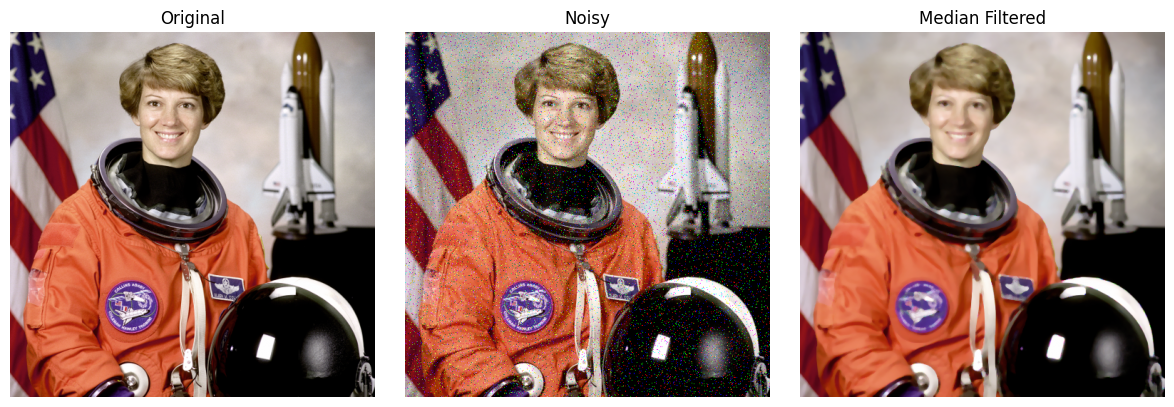

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# Grayscale
gray = img_as_float(data.camera())
gray_noisy = util.random_noise(gray, mode='s&p', amount=0.05)
gray_denoised = filters.median(gray_noisy, morphology.disk(3))

# Plot grayscale
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Noisy")
axes[1].axis('off')
axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Median Filtered")
axes[2].axis('off')
plt.tight_layout()
plt.show()

# Color
color = img_as_float(data.astronaut())
color_noisy = util.random_noise(color, mode='s&p', amount=0.05)
color_denoised = np.zeros_like(color)
for c in range(3):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# Plot color
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color)
axes2[0].set_title("Original")
axes2[0].axis('off')
axes2[1].imshow(color_noisy)
axes2[1].set_title("Noisy")
axes2[1].axis('off')
axes2[2].imshow(color_denoised)
axes2[2].set_title("Median Filtered")
axes2[2].axis('off')
plt.tight_layout()
plt.show()


# penugasan nomer 3

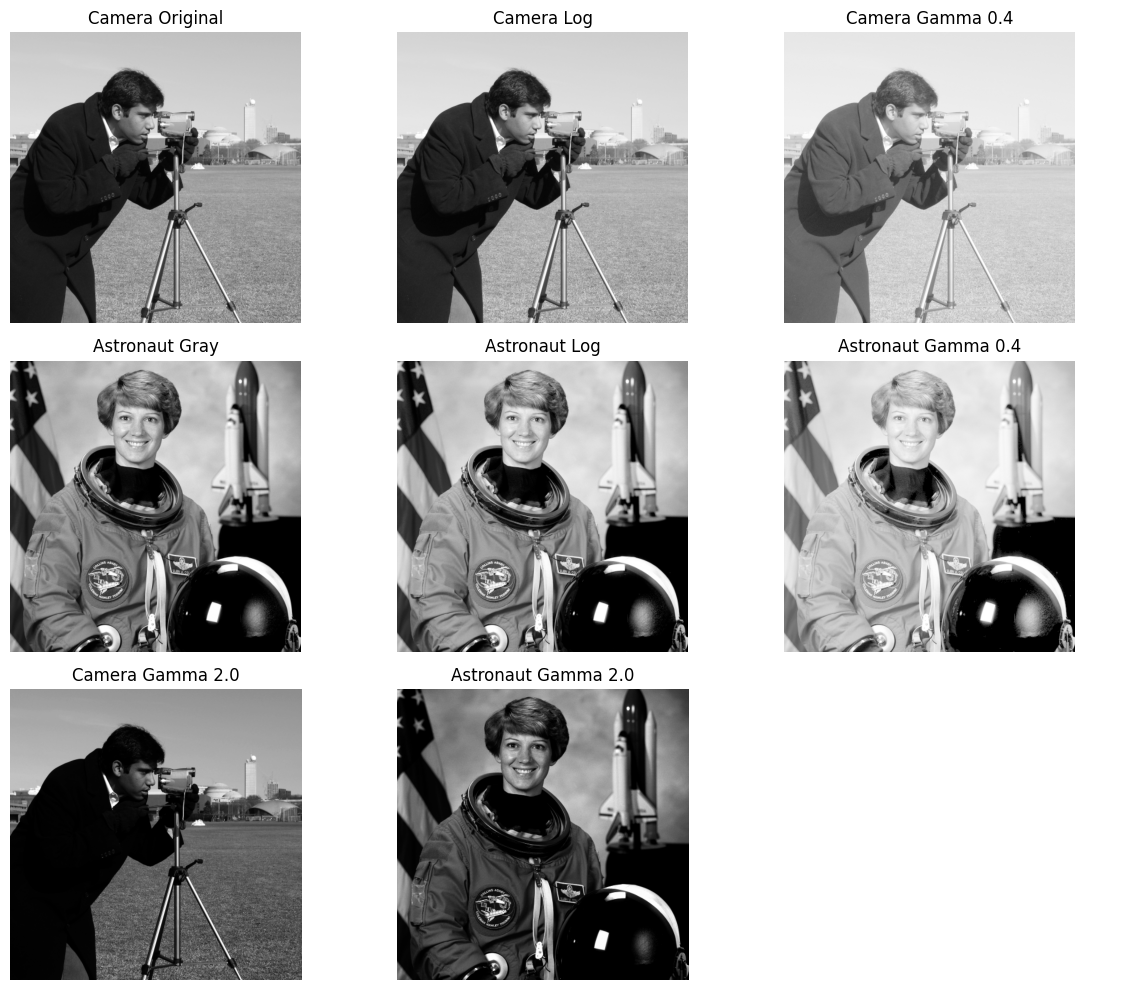

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, color, img_as_float

# Load grayscale images
camera = img_as_float(data.camera())
astronaut_gray = color.rgb2gray(data.astronaut())

# Log Transform
camera_log = exposure.adjust_log(camera)
astronaut_log = exposure.adjust_log(astronaut_gray)

# Gamma Transform (gamma < 1 = lebih terang, > 1 = lebih gelap)
camera_gamma04 = exposure.adjust_gamma(camera, gamma=0.4)
camera_gamma20 = exposure.adjust_gamma(camera, gamma=2.0)

# Plot
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
titles = ['Original', 'Log Transform', 'Gamma 0.4', 'Gamma 2.0']

# Camera
axes[0, 0].imshow(camera, cmap='gray'); axes[0, 0].set_title("Camera Original")
axes[0, 1].imshow(camera_log, cmap='gray'); axes[0, 1].set_title("Camera Log")
axes[0, 2].imshow(camera_gamma04, cmap='gray'); axes[0, 2].set_title("Camera Gamma 0.4")

# Astronaut
axes[1, 0].imshow(astronaut_gray, cmap='gray'); axes[1, 0].set_title("Astronaut Gray")
axes[1, 1].imshow(astronaut_log, cmap='gray'); axes[1, 1].set_title("Astronaut Log")
axes[1, 2].imshow(exposure.adjust_gamma(astronaut_gray, gamma=0.4), cmap='gray')
axes[1, 2].set_title("Astronaut Gamma 0.4")

# Gamma 2.0
axes[2, 0].imshow(exposure.adjust_gamma(camera, gamma=2.0), cmap='gray')
axes[2, 0].set_title("Camera Gamma 2.0")
axes[2, 1].imshow(exposure.adjust_gamma(astronaut_gray, gamma=2.0), cmap='gray')
axes[2, 1].set_title("Astronaut Gamma 2.0")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


#penugasan nomer 4

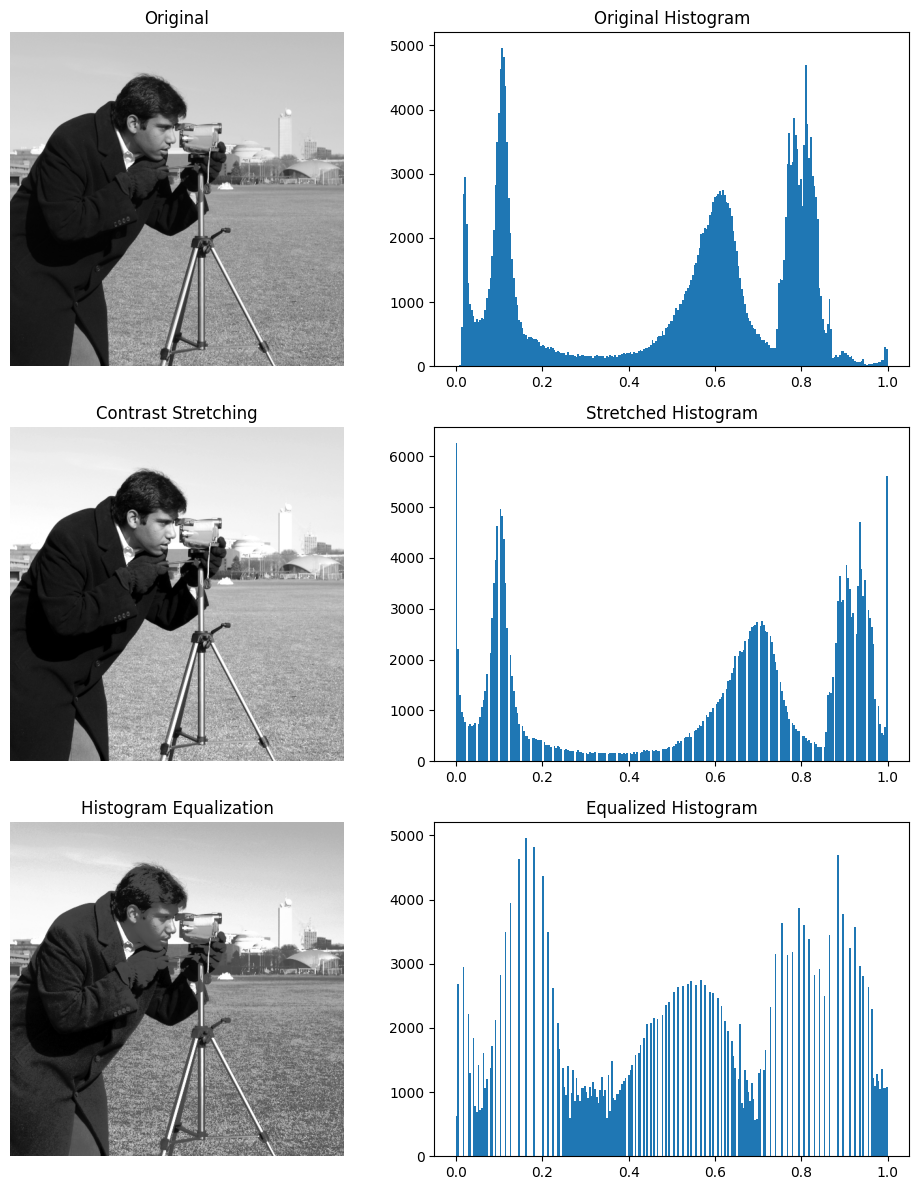

In [7]:
from skimage import exposure

image = img_as_float(data.camera())

# Contrast Stretching
p2, p98 = np.percentile(image, (2, 98))
image_stretch = exposure.rescale_intensity(image, in_range=(p2, p98))

# Histogram Equalization
image_eq = exposure.equalize_hist(image)

# Plot and Histogram
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].imshow(image, cmap='gray'); axes[0, 0].set_title("Original")
axes[0, 1].hist(image.ravel(), bins=256); axes[0, 1].set_title("Original Histogram")

axes[1, 0].imshow(image_stretch, cmap='gray'); axes[1, 0].set_title("Contrast Stretching")
axes[1, 1].hist(image_stretch.ravel(), bins=256); axes[1, 1].set_title("Stretched Histogram")

axes[2, 0].imshow(image_eq, cmap='gray'); axes[2, 0].set_title("Histogram Equalization")
axes[2, 1].hist(image_eq.ravel(), bins=256); axes[2, 1].set_title("Equalized Histogram")

for ax in axes[:, 0]: ax.axis('off')
plt.tight_layout()
plt.show()


#penugasan nomer 5

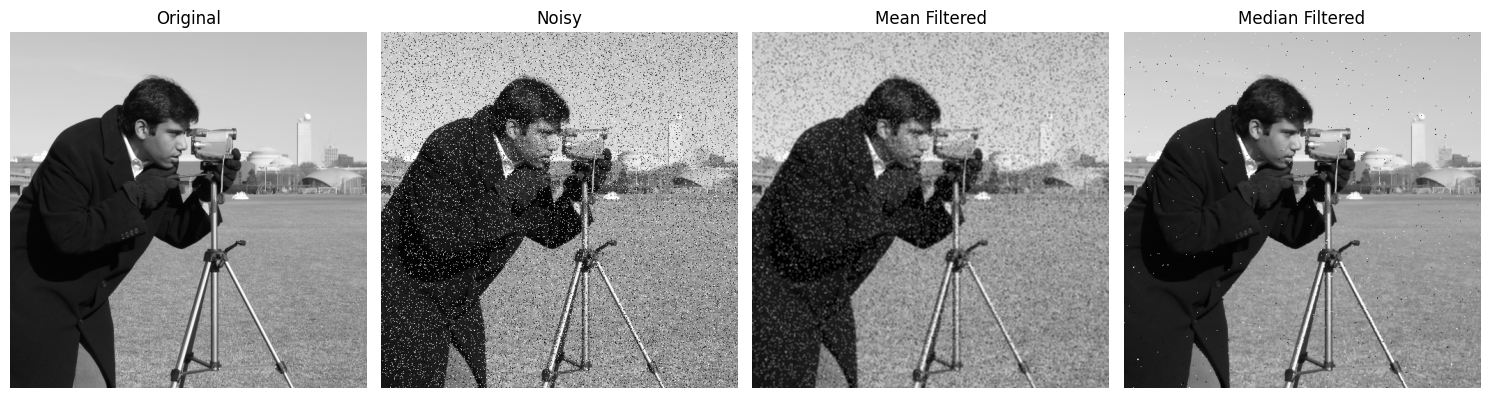

In [8]:
from skimage import util, filters, morphology
from scipy.ndimage import convolve

# Tambahkan noise
image = img_as_float(data.camera())
noisy = util.random_noise(image, mode='s&p', amount=0.1)

# Filter Rata-rata (Mean)
kernel = np.ones((3,3)) / 9
mean_filtered = convolve(noisy, kernel)

# Filter Median
median_filtered = filters.median(noisy, morphology.disk(1))

# Plot
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
titles = ['Original', 'Noisy', 'Mean Filtered', 'Median Filtered']
images = [image, noisy, mean_filtered, median_filtered]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()
